In [ ]:
!pip install pandas numpy seaborn matplotlib requests beautifulsoup4 requests_html lxml_html_clean selenium
!apt-get update
!apt install -y chromium-browser chromium-chromedriver

INFO: pip is looking at multiple versions of pyppeteer to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of pyppeteer to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 13.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.0/512.0 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 6.5 MB/s eta 0:00:00
  Created wheel for pyppeteer: filename=pyppeteer-0.0.25-py3-none-any.whl size=78356 sha256=51c3a76b68df7c34ca9eb2391496d83bfbc5f9f1db8b2aeb6fff2f281440d11f
  Stored in directory: /root/.cache/pip/wheels/9c/7e/08/1d19cd4b0f6d57363170cf9538d65a7285e6aba8731bac8813
Successfully built pyppeteer
Get:1 https://cli.github.com/packages stable InRele

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup


In [ ]:
# This dataset contains data from 2015-2022 of player information such as performance statistics and results from tournaments.


ranking_df = pd.read_csv("/content/ASA All PGA Raw Data - Tourn Level.csv")
ranking_df.head()

,Player_initial_last,tournament id,player id,hole_par,strokes,hole_DKP,hole_FDP,hole_SDP,streak_DKP,streak_FDP,...,purse,season,no_cut,Finish,sg_putt,sg_arg,sg_app,sg_ott,sg_t2g,sg_total
0,A. Ancer,401353224,9261,288,289,60.0,51.1,56,3,7.6,...,12.0,2022,0,T32,0.20,-0.13,-0.08,0.86,0.65,0.85
1,A. Hadwin,401353224,5548,288,286,72.5,61.5,61,8,13.0,...,12.0,2022,0,T18,0.36,0.75,0.31,0.18,1.24,1.60
2,A. Lahiri,401353224,4989,144,147,21.5,17.4,27,0,0.0,...,12.0,2022,0,CUT,-0.56,0.74,-1.09,0.37,0.02,-0.54
3,A. Long,401353224,6015,144,151,20.5,13.6,17,0,0.4,...,12.0,2022,0,CUT,-1.46,-1.86,-0.02,0.80,-1.08,-2.54
4,A. Noren,401353224,3832,144,148,23.5,18.1,23,0,1.2,...,12.0,2022,0,CUT,0.53,-0.36,-1.39,0.19,-1.56,-1.04


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Connecting to URL and Inspected**



*   Connected to the url using urllib to download the raw HTML of the 2015 golf stats page.
*   Decoded and parsed the HTML content using BeautifulSoup to make it easier to read and extract data.
*   Inspected the HTML structure to identify where player statistics (like names, ranks and earnings) are located for scraping.





In [ ]:
import http.client
import urllib.request

http.client._MAXHEADERS = 1000
# Parsing the httml
url = "https://www.espn.com/golf/stats/player/_/season/2015"
response = urllib.request.urlopen(url)
raw_html = response.read().decode("utf-8")
soup = BeautifulSoup(raw_html, 'html.parser')
print(soup)


<!DOCTYPE html>

<html lang="en">
<head>
<meta charset="utf-8"/>
<!-- ESPNFITT | b222a8eb5092 | 13585631 | 9b8e421a | www.espn.com | Fri, 14 Nov 2025 16:35:42 GMT -->
<script src="https://dcf.espn.com/TWDC-DTCI/prod/Bootstrap.js"></script>
<script>
            (function(h,o,u,n,d) {
                h=h[d]=h[d]||{q:[],onReady:function(c){h.q.push(c)}}
                d=o.createElement(u);d.async=1;d.src=n
                n=o.getElementsByTagName(u)[0];n.parentNode.insertBefore(d,n)
            })(window,document,'script','https://www.datadoghq-browser-agent.com/us1/v5/datadog-rum.js','DD_RUM');
            
            window.DD_RUM.onReady(function() {
                window.DD_RUM.setGlobalContext({
                    twdcgrid: {
                        yp_team_id: "67c86818ce5ff1871b58289f",
                        yp_service_id: "67b8d8e244357475ee4bd4b4",
                        datadog_log_index: "observability"
                    }
                });
            });
        <

# **Locating all tables**



*   Used BeautifulSoup to locate all the HTML tables on the ESPN webpage
*   Converted the table HTML into a Pandas DataFrame using pd.read_html() and io.StringIO to handle string input safely as I had got an error telling me to ensure that I use io.StringIO from colab.
*   Displayed the DataFrame to view the table data and check the available columns.






In [ ]:
import io
# reading the datafram for column names, imported io as colab gave previous warning when reading the html string.
table = soup.find_all("table")
df = pd.read_html(io.StringIO(str(table)))[0]
print(df)

    RK              Name  AGE
0    1     Jordan Spieth   32
1    2         Jason Day   38
2    3      Bubba Watson   47
3    4     Rickie Fowler   36
4    5    Dustin Johnson   41
5    6       Justin Rose   45
6    7      Rory McIlroy   36
7    8      Zach Johnson   49
8    9    Henrik Stenson   49
9   10      Jimmy Walker   46
10  11   Charley Hoffman   48
11  12       J.B. Holmes   43
12  13         Danny Lee   35
13  14      Robert Streb   38
14  15  Hideki Matsuyama   33
15  16         Jim Furyk   55
16  17   Brandt Snedeker   44
17  18      Patrick Reed   35
18  19     Brooks Koepka   35
19  20      Kevin Kisner   41
20  21        Paul Casey   48
21  22  Louis Oosthuizen   43
22  23   Steven Bowditch   42
23  24         Bill Haas   43
24  25     Daniel Berger   32
25  26          Kevin Na   42
26  27      Scott Piercy   47
27  28       Matt Kuchar   47
28  29   David Lingmerth   38
29  30        Ben Martin   38
30  31     Sergio Garcia   45
31  32        Ryan Moore   42
32  33    

# **ESPN Table Only Displayed Rank, Name, and Age**

When scraping the ESPN stats page using urllib and BeautifulSoup, the HTML table only showed Rank, Name and Age, while the Earnings column was missing. I explain how I fixed this in my word document.

In [ ]:
import requests
from bs4 import BeautifulSoup
import re
import pandas as pd

url = "https://www.espn.com/golf/stats/player/_/season/2015"

headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept-Language": "en-US,en;q=0.9",
}

html = requests.get(url, headers=headers).text
soup = BeautifulSoup(html, "html.parser")

# SCRAPE all player names
player_tags = soup.find_all("a", href=re.compile(r"/golf/player/_/id/"))
player_names = [tag.get_text(strip=True) for tag in player_tags]

# SCRAPE earnings (only valid money values)

earnings = re.findall(r"\$\d{1,3}(?:,\d{3})+", html)

# ALIGN top 50

player_names = player_names[:50]
earnings = earnings[:50]

df = pd.DataFrame({
    "player_name": player_names,
    "earnings_str": earnings
})

df["earnings"] = df["earnings_str"].str.replace("[$,]", "", regex=True).astype(int)

df.head(50)















,player_name,earnings_str,earnings
0,Jordan Spieth,"$12,030,465",12030465
1,Jason Day,"$9,403,330",9403330
2,Bubba Watson,"$6,876,797",6876797
3,Rickie Fowler,"$5,773,430",5773430
4,Dustin Johnson,"$5,509,467",5509467
5,Justin Rose,"$5,462,677",5462677
6,Rory McIlroy,"$4,863,312",4863312
7,Zach Johnson,"$4,801,487",4801487
8,Henrik Stenson,"$4,755,070",4755070
9,Jimmy Walker,"$4,521,350",4521350


In [ ]:
# Saved the merged dataframe to a CSV file without including row index numbers
df.to_csv("merged_data.csv", index=False)


# **Merging Names and Earnings from top 50 ranked earners from ESPN 2015 data**

In [ ]:
import pandas as pd

# df = ESPN scraped dataframe (with 'player_name' + 'earnings')
# ranking_df = Kaggle dataset

# 1. Making short version of ESPN names to match Kaggle format
def shorten_name(full_name):
    """
    Converts 'First Last' → 'F. Last'
    Example:
    'Abraham Ancer' → 'A. Ancer'
    """
    parts = full_name.split()
    first_initial = parts[0][0] + "."
    last_name = parts[-1]
    return f"{first_initial} {last_name}"

df["player_name_short"] = df["player_name"].apply(shorten_name)

# 2. Clean both name columns (lowercase + strip)
df["player_name_short"] = df["player_name_short"].str.lower().str.strip()
ranking_df["Player_initial_last"] = ranking_df["Player_initial_last"].str.lower().str.strip()

# 3. MERGE (only merging earnings + short name)
df_merged = ranking_df.merge(
    df[["player_name_short", "earnings"]],   # <-- removed earnings_str here
    left_on="Player_initial_last",
    right_on="player_name_short",
    how="left"
)

# 4. Replace NaN earnings with 'Not Ranked'
df_merged["earnings"] = df_merged["earnings"].fillna("Not Ranked")

# OPTIONAL: drop helper column if you don’t want it
df_merged = df_merged.drop(columns=["player_name_short"])

# 5. Show output
df_merged.head(50)


,Player_initial_last,tournament id,player id,hole_par,strokes,hole_DKP,hole_FDP,hole_SDP,streak_DKP,streak_FDP,...,season,no_cut,Finish,sg_putt,sg_arg,sg_app,sg_ott,sg_t2g,sg_total,earnings
0,a. ancer,401353224,9261,288,289,60.0,51.1,56,3,7.6,...,2022,0,T32,0.20,-0.13,-0.08,0.86,0.65,0.85,Not Ranked
1,a. hadwin,401353224,5548,288,286,72.5,61.5,61,8,13.0,...,2022,0,T18,0.36,0.75,0.31,0.18,1.24,1.60,Not Ranked
2,a. lahiri,401353224,4989,144,147,21.5,17.4,27,0,0.0,...,2022,0,CUT,-0.56,0.74,-1.09,0.37,0.02,-0.54,Not Ranked
3,a. long,401353224,6015,144,151,20.5,13.6,17,0,0.4,...,2022,0,CUT,-1.46,-1.86,-0.02,0.80,-1.08,-2.54,Not Ranked
4,a. noren,401353224,3832,144,148,23.5,18.1,23,0,1.2,...,2022,0,CUT,0.53,-0.36,-1.39,0.19,-1.56,-1.04,Not Ranked
5,a. putnam,401353224,5502,144,151,19.5,12.0,19,0,6.0,...,2022,0,CUT,-0.97,0.14,-2.02,0.31,-1.56,-2.54,Not Ranked
6,a. rai,401353224,10906,288,287,63.0,55.7,58,3,7.2,...,2022,0,T26,2.05,0.74,-1.32,-0.12,-0.70,1.35,Not Ranked
7,a. schenk,401353224,10372,288,287,59.5,54.0,59,0,7.8,...,2022,0,T26,-0.96,-0.01,1.84,0.48,2.31,1.35,Not Ranked
8,a. scott,401353224,388,288,299,48.5,34.7,48,0,5.4,...,2022,0,T67,-0.82,-1.79,2.00,-1.04,-0.83,-1.65,Not Ranked
9,a. smalley,401353224,9484,144,151,18.0,10.9,20,0,0.6,...,2022,0,CUT,-1.89,-0.71,0.71,-0.65,-0.65,-2.54,Not Ranked


In [ ]:
# 1. Convert earnings to numeric, keep Not Ranked as NaN
df_merged["earnings_numeric"] = pd.to_numeric(
    df_merged["earnings"], errors="coerce"
)

# 2. Create ranking (1 = highest earnings)
df_merged["money_rank"] = df_merged["earnings_numeric"].rank(
    method="dense", ascending=False
)

# 3. Replace NaN ranks with "Not Ranked"
df_merged["money_rank"] = df_merged["money_rank"].fillna("Not Ranked")

# 4. drop the numeric helper column
df_merged = df_merged.drop(columns=["earnings_numeric"])

# View the first rows
df_merged.head(20)


,Player_initial_last,tournament id,player id,hole_par,strokes,hole_DKP,hole_FDP,hole_SDP,streak_DKP,streak_FDP,...,no_cut,Finish,sg_putt,sg_arg,sg_app,sg_ott,sg_t2g,sg_total,earnings,money_rank
0,a. ancer,401353224,9261,288,289,60.0,51.1,56,3,7.6,...,0,T32,0.20,-0.13,-0.08,0.86,0.65,0.85,Not Ranked,Not Ranked
1,a. hadwin,401353224,5548,288,286,72.5,61.5,61,8,13.0,...,0,T18,0.36,0.75,0.31,0.18,1.24,1.60,Not Ranked,Not Ranked
2,a. lahiri,401353224,4989,144,147,21.5,17.4,27,0,0.0,...,0,CUT,-0.56,0.74,-1.09,0.37,0.02,-0.54,Not Ranked,Not Ranked
3,a. long,401353224,6015,144,151,20.5,13.6,17,0,0.4,...,0,CUT,-1.46,-1.86,-0.02,0.80,-1.08,-2.54,Not Ranked,Not Ranked
4,a. noren,401353224,3832,144,148,23.5,18.1,23,0,1.2,...,0,CUT,0.53,-0.36,-1.39,0.19,-1.56,-1.04,Not Ranked,Not Ranked
5,a. putnam,401353224,5502,144,151,19.5,12.0,19,0,6.0,...,0,CUT,-0.97,0.14,-2.02,0.31,-1.56,-2.54,Not Ranked,Not Ranked
6,a. rai,401353224,10906,288,287,63.0,55.7,58,3,7.2,...,0,T26,2.05,0.74,-1.32,-0.12,-0.70,1.35,Not Ranked,Not Ranked
7,a. schenk,401353224,10372,288,287,59.5,54.0,59,0,7.8,...,0,T26,-0.96,-0.01,1.84,0.48,2.31,1.35,Not Ranked,Not Ranked
8,a. scott,401353224,388,288,299,48.5,34.7,48,0,5.4,...,0,T67,-0.82,-1.79,2.00,-1.04,-0.83,-1.65,Not Ranked,Not Ranked
9,a. smalley,401353224,9484,144,151,18.0,10.9,20,0,0.6,...,0,CUT,-1.89,-0.71,0.71,-0.65,-0.65,-2.54,Not Ranked,Not Ranked


# **Filtering to only ranked players**


In [ ]:
# Create a new dataframe containing only players with valid earnings rankings and convert their ranks to integers
df_top50 = df_merged[df_merged["money_rank"] != "Not Ranked"].copy()
df_top50["money_rank"] = df_top50["money_rank"].astype(int)
df_top50.head(20)

,Player_initial_last,tournament id,player id,hole_par,strokes,hole_DKP,hole_FDP,hole_SDP,streak_DKP,streak_FDP,...,Finish,sg_putt,sg_arg,sg_app,sg_ott,sg_t2g,sg_total,earnings,money_rank,overall_2015_rank
18,b. snedeker,401353224,1222,288,295,48.0,37.7,48,0,1.0,...,T60,1.12,0.25,-1.10,-0.92,-1.77,-0.65,3698056.0,17,60.0
24,c. hoffman,401353224,205,144,147,26.0,20.7,24,0,5.6,...,CUT,-0.20,-0.47,0.14,0.00,-0.34,-0.54,4041089.0,11,200.0
27,c. kirk,401353224,3449,288,294,60.0,46.3,47,0,12.4,...,T53,-0.02,0.45,-1.28,0.45,-0.38,-0.40,2369326.0,35,53.0
33,c. tringale,401353224,4645,288,292,52.5,43.3,53,0,6.0,...,T48,-0.18,0.35,-0.67,0.59,0.28,0.10,1837164.0,49,48.0
36,d. berger,401353224,9025,288,282,70.0,65.0,68,0,7.6,...,T5,1.65,-0.50,1.34,0.10,0.95,2.60,3028901.0,25,5.0
38,d. lee,401353224,3950,144,147,22.5,19.0,25,0,0.4,...,CUT,-1.75,-0.65,1.11,0.75,1.21,-0.54,3965933.0,13,200.0
39,d. lingmerth,401353224,5574,288,292,54.0,44.4,52,0,7.4,...,T48,0.09,-0.80,1.05,-0.24,0.01,0.10,2736378.0,29,48.0
48,g. woodland,401353224,3550,144,149,19.0,14.9,22,0,0.4,...,CUT,-1.19,-0.24,-0.86,0.75,-0.35,-1.54,2605083.0,33,200.0
49,h. english,401353224,5408,144,154,14.5,4.3,17,0,0.2,...,CUT,0.21,-0.03,-1.49,-2.73,-4.25,-4.04,1971687.0,47,200.0
52,j. day,401353224,1680,288,288,60.0,52.2,60,0,6.4,...,31,1.04,0.81,-0.87,0.13,0.06,1.10,9403330.0,2,31.0


In [15]:
def convert_finish(x):
    x = str(x)
    if x.startswith("T"):    # T32, T18
        return int(x[1:])
    if x == "CUT":
        return 200
    if x == "WIN":
        return 1
    return pd.to_numeric(x, errors="coerce")

# Convert Finish values to numeric
ranking_df["overall_2015_rank"] = ranking_df["Finish"].apply(convert_finish)

# Creating ONE overall 2015 ranking per player (mean finish across all tournaments)
player_overall_rank = ranking_df.groupby("Player_initial_last")["overall_2015_rank"].mean().reset_index()

# Rename for clarity
player_overall_rank.rename(columns={"overall_2015_rank": "overall_2015_avg_rank"}, inplace=True)

player_overall_rank.head()

print(ranking_df)


      Player_initial_last  tournament id  player id  hole_par  strokes  \
0                a. ancer      401353224       9261       288      289   
1               a. hadwin      401353224       5548       288      286   
2               a. lahiri      401353224       4989       144      147   
3                 a. long      401353224       6015       144      151   
4                a. noren      401353224       3832       144      148   
...                   ...            ...        ...       ...      ...   
36859            v. singh           2271        392       144      146   
36860              w. kim           2271       7082       144      150   
36861           w. mcgirt           2271       3532       216      215   
36862            z. blair           2271       9040       288      278   
36863           z. sucher           2271       4708       144      147   

       hole_DKP  hole_FDP  hole_SDP  streak_DKP  streak_FDP  ...  season  \
0          60.0      51.1        56

In [20]:
#Merge each player's calculated overall 2015 average finish into the main dataset by matching on player name
df_merged = df_merged.merge(
    player_overall_rank,
    on="Player_initial_last",
    how="left"
)



In [17]:
df_top50 = df_merged[df_merged["money_rank"] != "Not Ranked"].copy()
df_top50["money_rank"] = df_top50["money_rank"].astype(int)


In [18]:
# Checking column names
df_merged.columns.tolist()


['Player_initial_last',
 'tournament id',
 'player id',
 'hole_par',
 'strokes',
 'hole_DKP',
 'hole_FDP',
 'hole_SDP',
 'streak_DKP',
 'streak_FDP',
 'streak_SDP',
 'n_rounds',
 'made_cut',
 'pos',
 'finish_DKP',
 'finish_FDP',
 'finish_SDP',
 'total_DKP',
 'total_FDP',
 'total_SDP',
 'player',
 'Unnamed: 2',
 'Unnamed: 3',
 'Unnamed: 4',
 'tournament name',
 'course',
 'date',
 'purse',
 'season',
 'no_cut',
 'Finish',
 'sg_putt',
 'sg_arg',
 'sg_app',
 'sg_ott',
 'sg_t2g',
 'sg_total',
 'earnings',
 'money_rank',
 'overall_2015_rank']

In [19]:
# Checking Player , Money Rank and overall rank
df_top50[["Player_initial_last", "money_rank", "overall_2015_rank"]].head(50)


,Player_initial_last,money_rank,overall_2015_rank
18,b. snedeker,17,60.0
24,c. hoffman,11,200.0
27,c. kirk,35,53.0
33,c. tringale,49,48.0
36,d. berger,25,5.0
38,d. lee,13,200.0
39,d. lingmerth,29,48.0
48,g. woodland,33,200.0
49,h. english,47,200.0
52,j. day,2,31.0


In [ ]:
# Creating a new datframe from only season 2015
df_2015 = df_merged[df_merged["season"] == 2015].copy()


In [21]:
df.to_csv("season_2015.csv", index=False)

In [22]:
#Group the top-50 players and compute their average performance stats (putting, tee-to-green, finish) along with their earnings ranking

import pandas as pd

player_stats = df_top50.groupby("Player_initial_last").agg(
    sg_putt_mean = ("sg_putt",      lambda x: pd.to_numeric(x, errors="coerce").mean()),
    sg_t2g_mean  = ("sg_t2g",       lambda x: pd.to_numeric(x, errors="coerce").mean()),
    finish_mean  = ("Finish",  lambda x: pd.to_numeric(x, errors="coerce").mean()),
    money_rank   = ("money_rank",   lambda x: pd.to_numeric(x, errors="coerce").iloc[0])
).reset_index()



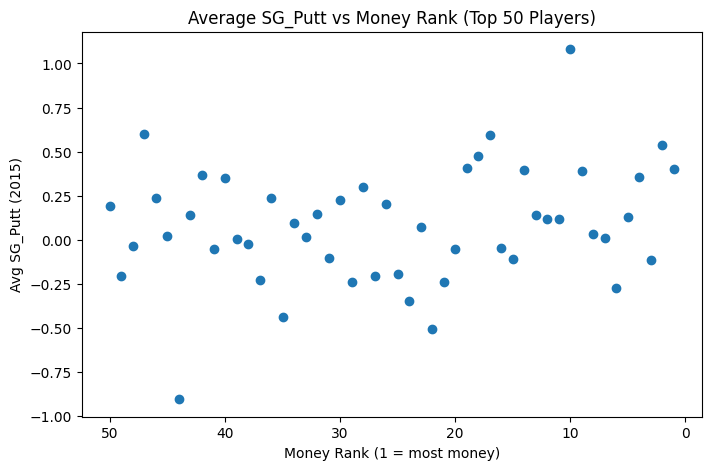

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(player_stats["money_rank"], player_stats["sg_putt_mean"])
plt.gca().invert_xaxis()
plt.xlabel("Money Rank (1 = most money)")
plt.ylabel("Avg SG_Putt (2015)")
plt.title("Average SG_Putt vs Money Rank (Top 50 Players)")
plt.show()


This graph did not give any meaningful insight as there is no standout points or statistics

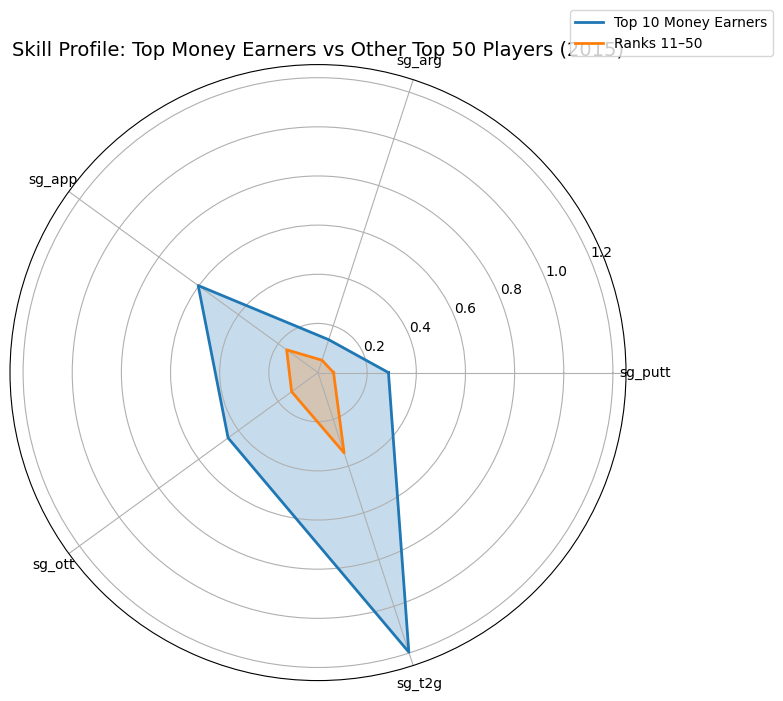

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Select SG columns
stats = ["sg_putt", "sg_arg", "sg_app", "sg_ott", "sg_t2g"]

# Group averages
top10 = df_top50[df_top50["money_rank"] <= 10][stats].mean()
rest40 = df_top50[(df_top50["money_rank"] > 10) & (df_top50["money_rank"] <= 50)][stats].mean()

# Radar setup
labels = stats
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
top10_values = top10.values.tolist()
rest40_values = rest40.values.tolist()

# close the circle
top10_values += top10_values[:1]
rest40_values += rest40_values[:1]
angles = np.concatenate((angles, [angles[0]]))

# Plot
plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

ax.plot(angles, top10_values, linewidth=2, label="Top 10 Money Earners")
ax.fill(angles, top10_values, alpha=0.25)

ax.plot(angles, rest40_values, linewidth=2, label="Ranks 11–50")
ax.fill(angles, rest40_values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
plt.title("Skill Profile: Top Money Earners vs Other Top 50 Players (2015)", fontsize=14)
plt.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))

plt.show()


This radar chart compares the average performance metrics of the top money earners against the rest of the top-50 players. It shows how the highest-earning golfers outperform other players across key strokes-gained categories, especially in tee-to-green play

/tmp/ipython-input-894954246.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="money_rank", y="sg_t2g", palette="viridis")


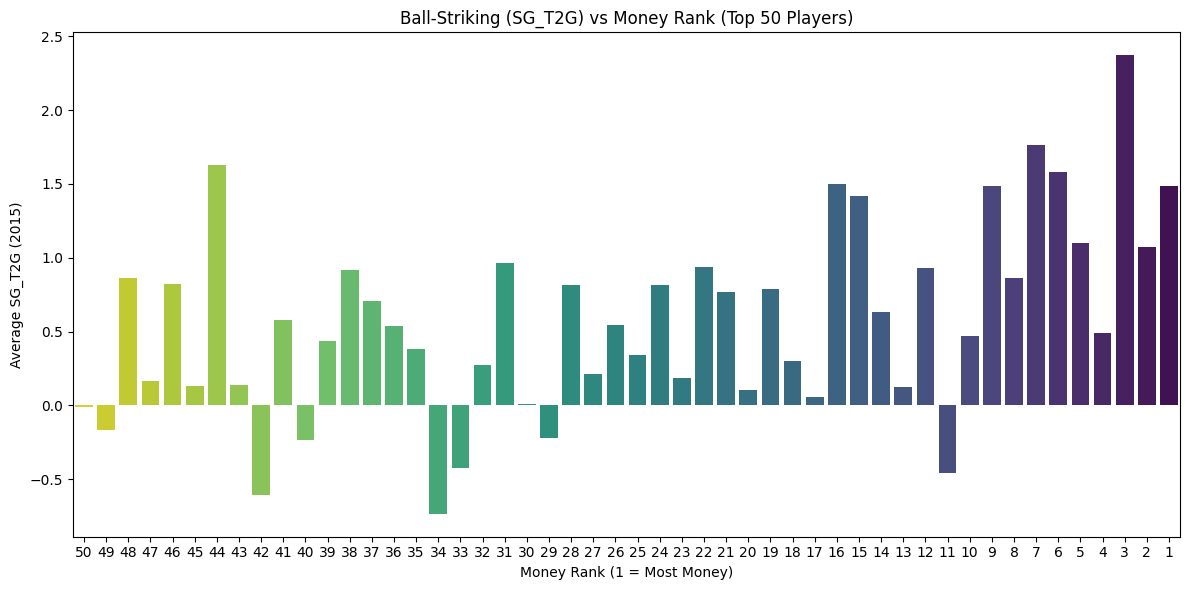

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Only top 50 players with SG_T2G available
plot_df = df_top50.groupby("Player_initial_last").agg({
    "sg_t2g": "mean",
    "money_rank": "first"
}).dropna().sort_values("money_rank")

plt.figure(figsize=(12,6))
sns.barplot(data=plot_df, x="money_rank", y="sg_t2g", palette="viridis")

plt.gca().invert_xaxis()   # Rank 1 on the left
plt.xlabel("Money Rank (1 = Most Money)")
plt.ylabel("Average SG_T2G (2015)")
plt.title("Ball-Striking (SG_T2G) vs Money Rank (Top 50 Players)")

plt.tight_layout()
plt.show()


This bar chart compares each top 50 players average tee-to-green performance with their money ranking. The plot shows a clear trend where the highest earning players generally have stronger SG_T2G values, suggesting that ball-striking ability is a major factor in financial success

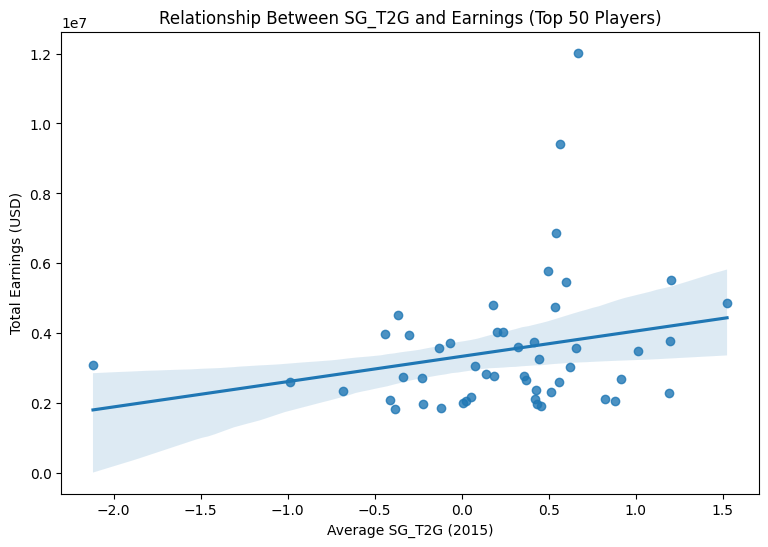

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use only players with earnings and SG_T2G data
scatter_df = df_top50.groupby("Player_initial_last").agg({
    "sg_t2g": "mean",
    "earnings": "first",
    "money_rank": "first"
}).dropna()

plt.figure(figsize=(9,6))
sns.regplot(data=scatter_df, x="sg_t2g", y="earnings")

plt.xlabel("Average SG_T2G (2015)")
plt.ylabel("Total Earnings (USD)")
plt.title("Relationship Between SG_T2G and Earnings (Top 50 Players)")

plt.show()


This scatter plot illustrates how average SG_T2G relates to total earnings among the top 50 players. The upward trend suggests that players with better tee-to-green performance tend to earn significantly more money over the season

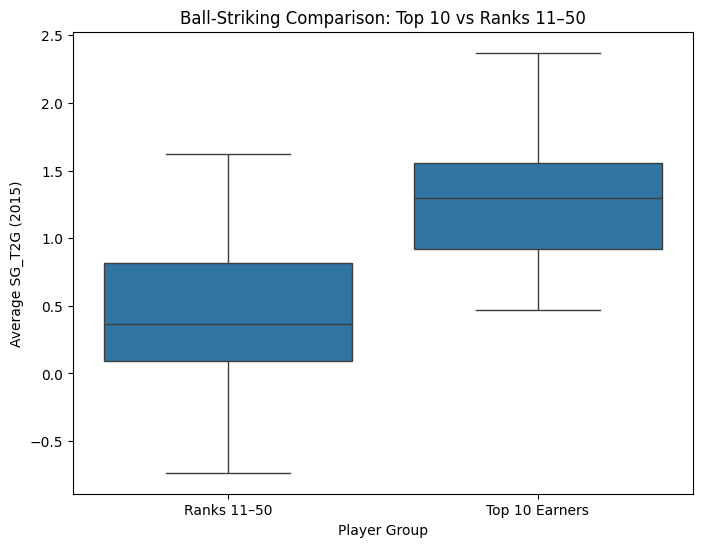

In [ ]:
# Categorize players into two groups
player_stats = df_top50.groupby("Player_initial_last").agg({
    "sg_t2g": "mean",
    "money_rank": "first"
}).dropna()

player_stats["group"] = player_stats["money_rank"].apply(
    lambda x: "Top 10 Earners" if x <= 10 else "Ranks 11–50"
)

plt.figure(figsize=(8,6))
sns.boxplot(data=player_stats, x="group", y="sg_t2g")

plt.xlabel("Player Group")
plt.ylabel("Average SG_T2G (2015)")
plt.title("Ball-Striking Comparison: Top 10 vs Ranks 11–50")

plt.show()


This boxplot compares ball striking performance between the top 10 earners and players ranked 11-50. The Top 10 group shows a much higher median SG_T2G, indicating that the highest-earning players tend to be significantly stronger tee-to-green